# DVS Gesture Recognition — CNN Results Visualization

Visualize test accuracy vs. target frame count, grouped by temporal pooling mode, averaged across random seeds.

Also compare against the baseline (no temporal pooling) from the original runs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and inspect pooled data

In [4]:
df = pd.read_csv("dvs128_cnn_09_batch8_10seeds.csv")
print(f"Total rows: {len(df)}")
print(f"Random seeds: {sorted(df['random_seed'].unique())}")
print(f"Target frames: {sorted(df['target_frames'].unique())}")
print(f"Pooling modes: {sorted(df['pooling_mode'].unique())}")
df.head()

Total rows: 594
Random seeds: [np.int64(6), np.int64(13), np.int64(42), np.int64(44), np.int64(45), np.int64(59), np.int64(93), np.int64(96), np.int64(98)]
Target frames: [np.int64(25), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800)]
Pooling modes: ['avg', 'linear', 'max']


,name,train_data_size,val_data_size,random_seed,representation,train_acc,val_acc,test_acc,num_epochs,batch_size,target_frames,pooling_mode
0,time_window_09_42_8_200_max,0.9,0.1,42,time_window,0.992783,0.897196,0.840909,8,8,200,max
1,time_window_09_42_8_300_max,0.9,0.1,42,time_window,0.991753,0.925234,0.871212,8,8,300,max
2,time_window_09_42_8_400_max,0.9,0.1,42,time_window,0.997938,0.897196,0.901515,8,8,400,max
3,time_window_09_42_8_500_max,0.9,0.1,42,time_window,1.000000,0.943925,0.875000,10,8,500,max
4,time_window_09_42_8_600_max,0.9,0.1,42,time_window,1.000000,0.934579,0.875000,14,8,600,max


## Load baseline results (no pooling)

In [5]:
df_baseline = pd.read_csv("../results/dvs128_cnn_09_batch8_10seeds.txt")
df_baseline_tw = df_baseline[df_baseline["representation"] == "time_window"].copy()
df_baseline_ts = df_baseline[df_baseline["representation"] == "timesurface"].copy()
print(f"Baseline time_window rows: {len(df_baseline_tw)}")
print(f"Baseline timesurface rows: {len(df_baseline_ts)}")

baseline_stats_tw = pd.Series({
    "train_acc_mean": df_baseline_tw["train_acc"].mean(),
    "train_acc_std":  df_baseline_tw["train_acc"].std(),
    "test_acc_mean":  df_baseline_tw["test_acc"].mean(),
    "test_acc_std":   df_baseline_tw["test_acc"].std(),
})
    
baseline_stats_ts = pd.Series({
    "train_acc_mean": df_baseline_ts["train_acc"].mean(),
    "train_acc_std":  df_baseline_ts["train_acc"].std(),
    "test_acc_mean":  df_baseline_ts["test_acc"].mean(),
    "test_acc_std":   df_baseline_ts["test_acc"].std(),
})

print(f"Baseline time_window test acc: {baseline_stats_tw['test_acc_mean']:.4f} \u00b1 {baseline_stats_tw['test_acc_std']:.4f}")
print(f"Baseline timesurface test acc: {baseline_stats_ts['test_acc_mean']:.4f} \u00b1 {baseline_stats_ts['test_acc_std']:.4f}")

Baseline time_window rows: 9
Baseline timesurface rows: 9
Baseline time_window test acc: 0.8847 ± 0.0291
Baseline timesurface test acc: 0.8838 ± 0.0290


## Average accuracies across random seeds (pooled runs)

In [6]:
avg_df = (
    df.groupby(["representation", "target_frames", "pooling_mode"])
    .agg(
        train_acc_mean=("train_acc", "mean"),
        train_acc_std=("train_acc", "std"),
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        n_runs=("test_acc", "count"),
    )
    .reset_index()
)
avg_df

,representation,target_frames,pooling_mode,train_acc_mean,train_acc_std,val_acc_mean,val_acc_std,test_acc_mean,test_acc_std,n_runs
0,time_window,25,avg,0.957961,0.038748,0.765317,0.051708,0.707912,0.041729,9
1,time_window,25,linear,0.993356,0.007145,0.737279,0.020069,0.675084,0.032017,9
2,time_window,25,max,0.979954,0.018940,0.782970,0.039313,0.723064,0.040062,9
3,time_window,50,avg,0.980298,0.018546,0.790239,0.071346,0.699495,0.041190,9
4,time_window,50,linear,0.995991,0.005887,0.749740,0.040137,0.707071,0.031121,9
...,...,...,...,...,...,...,...,...,...,...
61,timesurface,700,linear,0.995189,0.005763,0.943925,0.020369,0.893939,0.025268,9
62,timesurface,700,max,0.998625,0.002472,0.940810,0.016187,0.895202,0.016727,9
63,timesurface,800,avg,0.997938,0.004026,0.942887,0.024480,0.891414,0.015618,9
64,timesurface,800,linear,0.996793,0.004357,0.942887,0.018364,0.893519,0.018887,9


## Test accuracy vs. frame count by pooling mode, split by representation

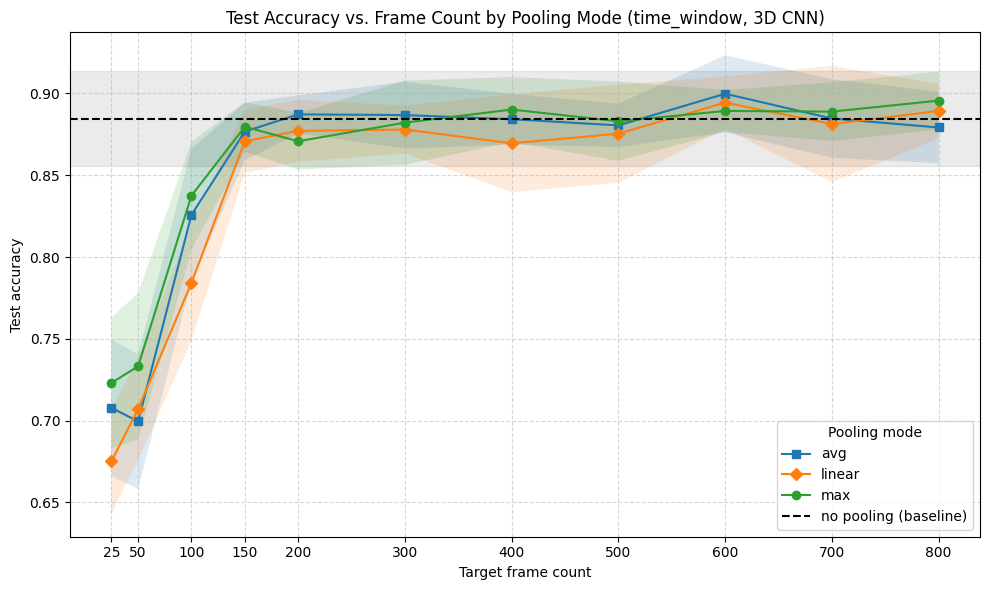

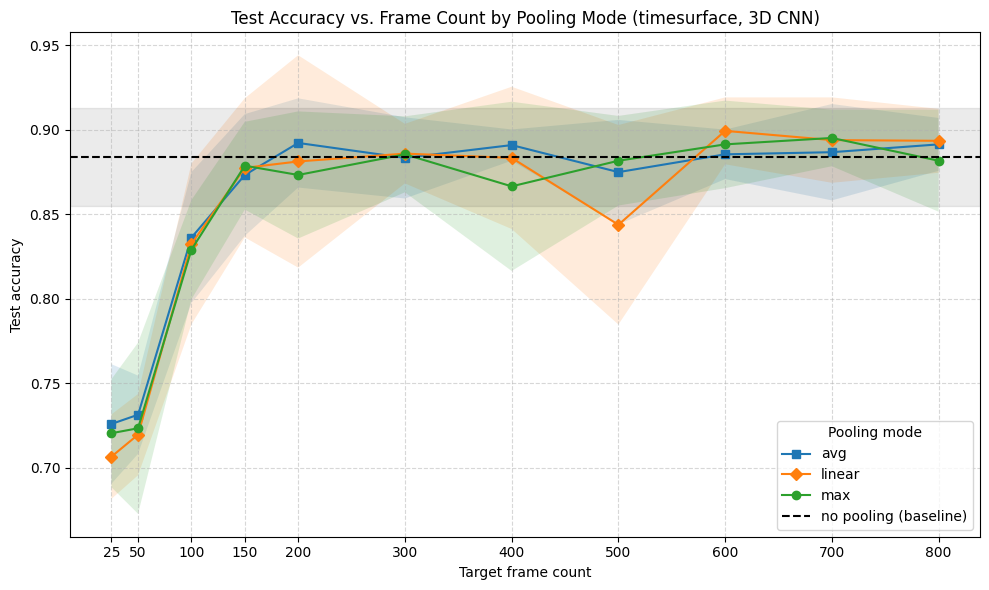

In [7]:
def plot_representation(rep_name, baseline_stats, title_suffix):
    rep_df = avg_df[avg_df["representation"] == rep_name].copy()

    fig, ax = plt.subplots(figsize=(10, 6))
    markers = {"max": "o", "avg": "s", "linear": "D"}

    for mode, grp in rep_df.groupby("pooling_mode"):
        grp = grp.sort_values("target_frames")
        ax.plot(
            grp["target_frames"],
            grp["test_acc_mean"],
            marker=markers.get(mode, "x"),
            label=mode,
        )
        ax.fill_between(
            grp["target_frames"],
            grp["test_acc_mean"] - grp["test_acc_std"],
            grp["test_acc_mean"] + grp["test_acc_std"],
            alpha=0.15,
        )

    bl_mean = baseline_stats["test_acc_mean"]
    bl_std = baseline_stats["test_acc_std"]
    ax.axhline(bl_mean, color="black", linestyle="--", linewidth=1.5, label="no pooling (baseline)")
    ax.axhspan(bl_mean - bl_std, bl_mean + bl_std, color="black", alpha=0.08)

    ax.set_xlabel("Target frame count")
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"Test Accuracy vs. Frame Count by Pooling Mode ({title_suffix}, 3D CNN)")
    ax.legend(title="Pooling mode")
    ax.set_xticks(sorted(rep_df["target_frames"].unique()))
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    return fig, ax


fig_time_window, ax_time_window = plot_representation(
    "time_window",
    baseline_stats_tw,
    "time_window",
)

fig_timesurface, ax_timesurface = plot_representation(
    "timesurface",
    baseline_stats_ts,
    "timesurface",
)

plt.show()

In [8]:
fig_time_window.savefig("output_time_window.png", dpi=150, bbox_inches="tight")
fig_timesurface.savefig("output_timesurface.png", dpi=150, bbox_inches="tight")